# mexari - Multimodal Spatio-Temporal Forecasting with PyG

Forecast municipal ARI mortality with a graph neural network that combines:
- past mortality
- exogenous weekly land surface temperature (LST) and precipitation
- static latitude and longitude attributes

This notebook is based on `spatiotemporal_forecasting_deep_graph_learning.ipynb`, but extends the node inputs from a univariate mortality window to a multimodal window with static geography.


## 1 - Optional environment setup

Uncomment the next cell if your environment is still missing PyTorch or PyTorch Geometric.


In [ ]:
# %pip install -U pandas matplotlib torch
# %pip install torch-geometric


## 2 - Imports and experiment configuration


In [1]:
from copy import deepcopy
from pathlib import Path
import importlib
import json
import sys

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

try:
    from torch_geometric.data import Batch, Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import SAGEConv
except ImportError as exc:
    raise ImportError(
        "This notebook requires `torch_geometric`. Install PyTorch and PyG before running it."
    ) from exc

import mexari as mx
mx = importlib.reload(mx)

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

WINDOW_WEEKS = 26
HORIZON_WEEKS = 4
STRIDE = 1
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEMPORAL_GAP = 4
BATCH_SIZE = 4
MAX_EPOCHS = 250
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 5e-4
PATIENCE = 50
LR_PATIENCE = 6

DYNAMIC_FEATURES = ["mortality", "lst", "precipitation"]
STATIC_FEATURES = ["latitude", "longitude"]

MORTALITY_CSV = Path(mx.DEFAULT_CSV)
LST_CSV = ROOT / "mexari" / "data" / "lst_data.csv"
PRECIP_CSV = ROOT / "mexari" / "data" / "precipitation_data.csv"

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

plt.style.use("seaborn-v0_8-whitegrid")

print(f"mexari version     : {mx.__version__}")
print(f"Mortality CSV      : {MORTALITY_CSV}")
print(f"LST CSV            : {LST_CSV}")
print(f"Precipitation CSV  : {PRECIP_CSV}")
print(f"Torch version      : {torch.__version__}")
print(f"Device             : {device}")
print(
    "Forecast setup     : "
    f"window={WINDOW_WEEKS}, horizon={HORIZON_WEEKS}, stride={STRIDE}, gap={TEMPORAL_GAP}"
)
print(f"Dynamic features   : {DYNAMIC_FEATURES}")
print(f"Static features    : {STATIC_FEATURES}")


mexari version     : 0.1.0
Mortality CSV      : /home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/mexari/data/mortality_rates.csv
LST CSV            : /home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/mexari/data/lst_data.csv
Precipitation CSV  : /home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/mexari/data/precipitation_data.csv
Torch version      : 2.11.0+cu128
Device             : cuda
Forecast setup     : window=26, horizon=4, stride=1, gap=4
Dynamic features   : ['mortality', 'lst', 'precipitation']
Static features    : ['latitude', 'longitude']


/home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 - Build the graph and recover a municipality lookup

`mexari.build_graph()` already gives us the graph structure, the municipality metadata, and the mortality time series. The LST and precipitation CSVs are keyed by `CVEGEO`, so we recover that lookup from the same GeoJSON order used to build the graph.


In [2]:
geojson_path = ROOT / "Data" / "mexico.geojson"

if not geojson_path.exists():
    raise FileNotFoundError(
        f"Set `geojson_path` to a local GeoJSON file before running the notebook: {geojson_path}"
    )

G = mx.build_graph(geojson_path=geojson_path)

with open(geojson_path, encoding="utf-8") as f:
    geo_features = json.load(f)["features"]

if len(geo_features) != G.number_of_nodes():
    raise ValueError(
        "The GeoJSON feature count does not match the graph node count. "
        "This notebook assumes `mx.build_graph()` preserves GeoJSON order."
    )

cvegeo_lookup = pd.DataFrame(
    [
        {"node": node_id, "cvegeo": feat["properties"]["CVEGEO"]}
        for node_id, feat in enumerate(geo_features)
    ]
).set_index("node")

X_np, node_order = mx.get_node_feature_matrix(G)
edge_index = torch.tensor(mx.get_edge_index(G, node_order), dtype=torch.long)
edge_weight = torch.ones(edge_index.shape[1], dtype=torch.float32)

week_labels = pd.Index(
    [
        f"{int(str(value).split('/')[0]):04d}/{int(str(value).split('/')[1]):02d}"
        for value in G.graph["dates"]
    ],
    name="epiweek",
)
mortality_df = pd.DataFrame(X_np.T, index=week_labels, columns=node_order)

node_frame = (
    pd.DataFrame(
        [
            {
                "node": node,
                "municipality": G.nodes[node]["municipality"],
                "state": G.nodes[node]["state"],
                "longitude": G.nodes[node]["longitude"],
                "latitude": G.nodes[node]["latitude"],
            }
            for node in node_order
        ]
    )
    .set_index("node")
    .join(cvegeo_lookup, how="left")
)

NUM_NODES = len(node_order)
NUM_WEEKS = len(week_labels)

print(f"Nodes                : {G.number_of_nodes()}")
print(f"Edges                : {G.number_of_edges()}")
print(f"Weekly observations  : {NUM_WEEKS}")
print(f"Density              : {nx.density(G):.5f}")
display(node_frame.head())


Nodes                : 2475
Edges                : 7246
Weekly observations  : 1148
Density              : 0.00237


,municipality,state,longitude,latitude,cvegeo
node,,,,,
0,San José de Gracia,Aguascalientes,-102.525839,22.146635,01008
1,Tepezalá,Aguascalientes,-102.192131,22.236974,01009
2,El Llano,Aguascalientes,-102.035399,21.921519,01010
3,San Francisco de los Romo,Aguascalientes,-102.229021,22.033071,01011
4,Aguascalientes,Aguascalientes,-102.295803,21.811436,01001


## 4 - Align mortality, LST, and precipitation on the same graph nodes

Mortality is already aligned to the graph through `mexari`. The exogenous CSVs have the same weekly span, but they store municipality codes as columns and use slightly different date formatting. We normalize dates, reindex to the graph order, and keep missing exogenous values as `NaN` until train-period scaling.


In [3]:
def normalize_epiweek(value):
    year, week = str(value).split("/")
    return f"{int(year):04d}/{int(week):02d}"


def load_exogenous_csv(path, week_labels, node_order, node_frame):
    ordered_cvegeo = node_frame.loc[node_order, "cvegeo"].tolist()
    df = pd.read_csv(path)
    df["Date"] = df["Date"].map(normalize_epiweek)
    df = (
        df.set_index("Date")
        .apply(pd.to_numeric, errors="coerce")
        .reindex(index=week_labels, columns=ordered_cvegeo)
    )
    df.columns = node_order
    return df


lst_df = load_exogenous_csv(LST_CSV, week_labels, node_order, node_frame)
precip_df = load_exogenous_csv(PRECIP_CSV, week_labels, node_order, node_frame)

source_summary = pd.DataFrame(
    [
        {
            "signal": "mortality",
            "weeks": mortality_df.shape[0],
            "nodes": mortality_df.shape[1],
            "missing_values": int(mortality_df.isna().sum().sum()),
        },
        {
            "signal": "lst",
            "weeks": lst_df.shape[0],
            "nodes": lst_df.shape[1],
            "missing_values": int(lst_df.isna().sum().sum()),
        },
        {
            "signal": "precipitation",
            "weeks": precip_df.shape[0],
            "nodes": precip_df.shape[1],
            "missing_values": int(precip_df.isna().sum().sum()),
        },
    ]
)

missing_exogenous_mask = lst_df.isna().all(axis=0) | precip_df.isna().all(axis=0)
missing_exogenous_nodes = node_frame.loc[
    missing_exogenous_mask[missing_exogenous_mask].index,
    ["cvegeo", "municipality", "state"],
]

print(f"Shared weekly span    : {week_labels[0]} to {week_labels[-1]}")
display(source_summary)

if missing_exogenous_nodes.empty:
    print("All municipalities have exogenous coverage.")
else:
    print(
        "Some municipalities are missing exogenous data. "
        "They will be imputed with the train-period mean after scaling."
    )
    display(missing_exogenous_nodes)


Shared weekly span    : 2003/01 to 2024/52


,signal,weeks,nodes,missing_values
0,mortality,1148,2475,0
1,lst,1148,2475,158613
2,precipitation,1148,2475,0


Some municipalities are missing exogenous data. They will be imputed with the train-period mean after scaling.


,cvegeo,municipality,state
131,07119,Santiago el Pinar,Chiapas
193,07091,Tapilula,Chiapas
199,07113,Aldama,Chiapas
283,09006,Iztacalco,Ciudad de México
729,15019,Capulhuac,México
...,...,...,...
2290,30185,Tlilapan,Veracruz de Ignacio de la Llave
2291,30186,Tomatlán,Veracruz de Ignacio de la Llave
2299,30199,Zaragoza,Veracruz de Ignacio de la Llave
2304,30206,Nanchital de Lázaro Cárdenas del Río,Veracruz de Ignacio de la Llave


## 5 - Quick sanity checks on the three input signals


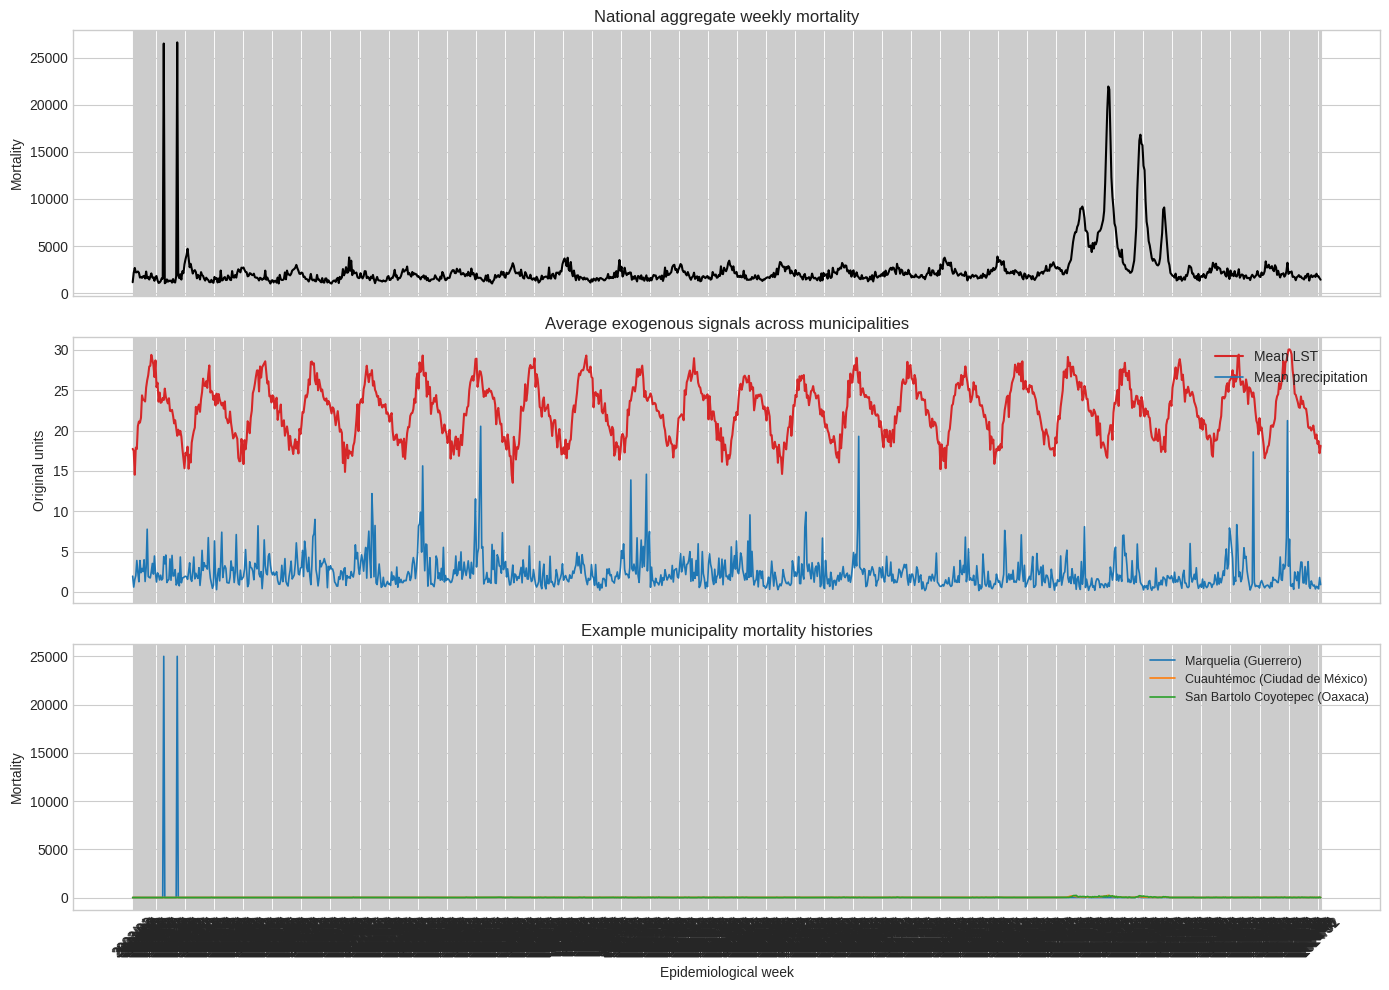

In [4]:
national_mortality = mortality_df.sum(axis=1)
mean_lst = lst_df.mean(axis=1, skipna=True)
mean_precip = precip_df.mean(axis=1, skipna=True)
top_nodes = mortality_df.mean(axis=0).sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(national_mortality.index, national_mortality.values, color="black", linewidth=1.5)
axes[0].set_title("National aggregate weekly mortality")
axes[0].set_ylabel("Mortality")

axes[1].plot(mean_lst.index, mean_lst.values, color="tab:red", linewidth=1.5, label="Mean LST")
axes[1].plot(
    mean_precip.index,
    mean_precip.values,
    color="tab:blue",
    linewidth=1.2,
    label="Mean precipitation",
)
axes[1].set_title("Average exogenous signals across municipalities")
axes[1].set_ylabel("Original units")
axes[1].legend(loc="upper right")

for node in top_nodes:
    label = f"{node_frame.loc[node, 'municipality']} ({node_frame.loc[node, 'state']})"
    axes[2].plot(mortality_df.index, mortality_df[node], linewidth=1.2, label=label)

axes[2].set_title("Example municipality mortality histories")
axes[2].set_ylabel("Mortality")
axes[2].set_xlabel("Epidemiological week")
axes[2].legend(loc="upper right", fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6 - Create multimodal graph samples with temporal windows and static features

Each sample is a `torch_geometric.data.Data` object:
- `x`: one graph snapshot with shape `(nodes, window, dynamic_features)`
- `static`: standardized latitude and longitude for each node
- `y`: the next `HORIZON_WEEKS` mortality values to forecast for each node

Mortality remains the prediction target. LST and precipitation are exogenous inputs only.


In [5]:
def compute_train_standardizer(values, train_end):
    train_values = values[:train_end]
    mean = torch.nanmean(train_values, dim=0, keepdim=True)
    centered = train_values - mean
    var = torch.nanmean(centered.square(), dim=0, keepdim=True)
    std = torch.sqrt(var).clamp_min(1e-6)

    mean = torch.nan_to_num(mean, nan=0.0, posinf=0.0, neginf=0.0)
    std = torch.nan_to_num(std, nan=1.0, posinf=1.0, neginf=1.0)
    return mean, std


def standardize(values, mean, std):
    scaled = (values - mean) / std
    return torch.nan_to_num(scaled, nan=0.0, posinf=0.0, neginf=0.0)


mortality_tensor = torch.tensor(mortality_df.to_numpy(), dtype=torch.float32)
lst_tensor = torch.tensor(lst_df.to_numpy(), dtype=torch.float32)
precip_tensor = torch.tensor(precip_df.to_numpy(), dtype=torch.float32)

dynamic_tensor = torch.stack(
    [mortality_tensor, lst_tensor, precip_tensor],
    dim=-1,
)
static_tensor = torch.tensor(
    node_frame.loc[node_order, STATIC_FEATURES].to_numpy(),
    dtype=torch.float32,
)

split = mx.make_temporal_split(
    num_weeks=NUM_WEEKS,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    gap=TEMPORAL_GAP,
)

train_starts = mx.region_window_starts(
    region_start=0,
    region_end=split.train_end,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    stride=STRIDE,
)
val_starts = mx.region_window_starts(
    region_start=split.val_start,
    region_end=split.val_end,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    stride=STRIDE,
)
test_starts = mx.region_window_starts(
    region_start=split.test_start,
    region_end=split.test_end,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    stride=STRIDE,
)

if not train_starts or not val_starts or not test_starts:
    raise ValueError(
        "Current split parameters do not leave enough room for train/val/test windows. "
        "Reduce `WINDOW_WEEKS`, reduce `TEMPORAL_GAP`, or adjust the split ratios."
    )

dynamic_mean, dynamic_std = compute_train_standardizer(dynamic_tensor, train_end=split.train_end)
scaled_dynamic_tensor = standardize(dynamic_tensor, dynamic_mean, dynamic_std)

mortality_mean = dynamic_mean[..., 0]
mortality_std = dynamic_std[..., 0]
target_tensor = scaled_dynamic_tensor[..., 0]

static_mean = static_tensor.mean(dim=0, keepdim=True)
static_std = static_tensor.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6)
scaled_static_tensor = (static_tensor - static_mean) / static_std


class MunicipalityMultimodalWindowDataset(Dataset):
    def __init__(
        self,
        dynamic_tensor,
        target_tensor,
        static_tensor,
        edge_index,
        edge_weight,
        window,
        horizon,
        starts,
    ):
        self.dynamic_tensor = dynamic_tensor
        self.target_tensor = target_tensor
        self.static_tensor = static_tensor
        self.edge_index = edge_index
        self.edge_weight = edge_weight
        self.window = window
        self.horizon = horizon
        self.starts = list(starts)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, idx):
        start = self.starts[idx]
        history = self.dynamic_tensor[start : start + self.window].permute(1, 0, 2).contiguous()
        target = self.target_tensor[
            start + self.window : start + self.window + self.horizon
        ].T.contiguous()

        data = Data(
            x=history,
            y=target,
            static=self.static_tensor,
            edge_index=self.edge_index,
            edge_weight=self.edge_weight,
        )
        data.window_start = torch.tensor([start], dtype=torch.long)
        data.target_start = torch.tensor([start + self.window], dtype=torch.long)
        return data


train_dataset = MunicipalityMultimodalWindowDataset(
    dynamic_tensor=scaled_dynamic_tensor,
    target_tensor=target_tensor,
    static_tensor=scaled_static_tensor,
    edge_index=edge_index,
    edge_weight=edge_weight,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    starts=train_starts,
)
val_dataset = MunicipalityMultimodalWindowDataset(
    dynamic_tensor=scaled_dynamic_tensor,
    target_tensor=target_tensor,
    static_tensor=scaled_static_tensor,
    edge_index=edge_index,
    edge_weight=edge_weight,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    starts=val_starts,
)
test_dataset = MunicipalityMultimodalWindowDataset(
    dynamic_tensor=scaled_dynamic_tensor,
    target_tensor=target_tensor,
    static_tensor=scaled_static_tensor,
    edge_index=edge_index,
    edge_weight=edge_weight,
    window=WINDOW_WEEKS,
    horizon=HORIZON_WEEKS,
    starts=test_starts,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample = train_dataset[0]

split_frame = pd.DataFrame(
    [
        {
            "split": "train",
            "history_start": week_labels[train_starts[0]],
            "history_end": week_labels[train_starts[-1] + WINDOW_WEEKS - 1],
            "target_end": week_labels[train_starts[-1] + WINDOW_WEEKS + HORIZON_WEEKS - 1],
            "n_windows": len(train_starts),
        },
        {
            "split": "validation",
            "history_start": week_labels[val_starts[0]],
            "history_end": week_labels[val_starts[-1] + WINDOW_WEEKS - 1],
            "target_end": week_labels[val_starts[-1] + WINDOW_WEEKS + HORIZON_WEEKS - 1],
            "n_windows": len(val_starts),
        },
        {
            "split": "test",
            "history_start": week_labels[test_starts[0]],
            "history_end": week_labels[test_starts[-1] + WINDOW_WEEKS - 1],
            "target_end": week_labels[test_starts[-1] + WINDOW_WEEKS + HORIZON_WEEKS - 1],
            "n_windows": len(test_starts),
        },
    ]
)

print(f"Train weeks          : 0 to {split.train_end - 1}")
print(f"Validation weeks     : {split.val_start} to {split.val_end - 1}")
print(f"Test weeks           : {split.test_start} to {split.test_end - 1}")
print(f"Train windows        : {len(train_dataset)}")
print(f"Val windows          : {len(val_dataset)}")
print(f"Test windows         : {len(test_dataset)}")
print(f"Dynamic tensor       : {tuple(dynamic_tensor.shape)}  (weeks x nodes x features)")
print(f"Static tensor        : {tuple(static_tensor.shape)}  (nodes x static_features)")
print(f"Sample x             : {tuple(sample.x.shape)}  (nodes x window x dynamic_features)")
print(f"Sample static        : {tuple(sample.static.shape)}  (nodes x static_features)")
print(f"Sample y             : {tuple(sample.y.shape)}  (nodes x horizon)")

split_frame


Train weeks          : 0 to 917
Validation weeks     : 922 to 1035
Test weeks           : 1040 to 1147
Train windows        : 889
Val windows          : 85
Test windows         : 79
Dynamic tensor       : (1148, 2475, 3)  (weeks x nodes x features)
Static tensor        : (2475, 2)  (nodes x static_features)
Sample x             : (2475, 26, 3)  (nodes x window x dynamic_features)
Sample static        : (2475, 2)  (nodes x static_features)
Sample y             : (2475, 4)  (nodes x horizon)


,split,history_start,history_end,target_end,n_windows
0,train,2003/01,2020/27,2020/31,889
1,validation,2020/36,2022/40,2022/44,85
2,test,2022/49,2024/48,2024/52,79


## 7 - Define a multimodal PyG forecaster

The model uses:
- a bidirectional GRU to encode the multivariate temporal window at each municipality
- a small MLP to encode static latitude and longitude
- GraphSAGE layers to propagate information over the municipal adjacency graph
- an MLP decoder to predict the next `HORIZON_WEEKS` mortality values


In [6]:
class MultimodalPyGForecaster(nn.Module):
    def __init__(
        self,
        dynamic_dim,
        static_dim,
        horizon,
        temporal_hidden=48,
        static_hidden=16,
        spatial_hidden=96,
        dropout=0.25,
    ):
        super().__init__()
        self.dropout = dropout

        self.temporal_encoder = nn.GRU(
            input_size=dynamic_dim,
            hidden_size=temporal_hidden,
            num_layers=2,
            dropout=dropout,
            batch_first=True,
            bidirectional=True,
        )
        self.static_encoder = nn.Sequential(
            nn.Linear(static_dim, static_hidden),
            nn.GELU(),
            nn.LayerNorm(static_hidden),
        )
        self.input_projection = nn.Linear(
            temporal_hidden * 2 + static_hidden,
            spatial_hidden,
        )
        self.sage1 = SAGEConv(spatial_hidden, spatial_hidden)
        self.sage2 = SAGEConv(spatial_hidden, spatial_hidden)
        self.norm1 = nn.LayerNorm(spatial_hidden)
        self.norm2 = nn.LayerNorm(spatial_hidden)
        self.decoder = nn.Sequential(
            nn.Linear(spatial_hidden, spatial_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(spatial_hidden, horizon),
        )

    def forward(self, data):
        _, hidden = self.temporal_encoder(data.x)
        temporal_h = torch.cat([hidden[-2], hidden[-1]], dim=-1)
        static_h = self.static_encoder(data.static)

        z = torch.cat([temporal_h, static_h], dim=-1)
        z = self.input_projection(z)

        residual = z
        z = self.sage1(z, data.edge_index)
        z = F.gelu(z)
        z = F.dropout(z, p=self.dropout, training=self.training)
        z = self.norm1(z + residual)

        residual = z
        z = self.sage2(z, data.edge_index)
        z = F.gelu(z)
        z = F.dropout(z, p=self.dropout, training=self.training)
        z = self.norm2(z + residual)

        return self.decoder(z)


model = MultimodalPyGForecaster(
    dynamic_dim=len(DYNAMIC_FEATURES),
    static_dim=len(STATIC_FEATURES),
    horizon=HORIZON_WEEKS,
    temporal_hidden=48,
    static_hidden=16,
    spatial_hidden=96,
    dropout=0.25,
).to(device)

n_params = sum(param.numel() for param in model.parameters())
print(model)
print(f"Trainable parameters: {n_params:,}")


MultimodalPyGForecaster(
  (temporal_encoder): GRU(3, 48, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (static_encoder): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (input_projection): Linear(in_features=112, out_features=96, bias=True)
  (sage1): SAGEConv(96, 96, aggr=mean)
  (sage2): SAGEConv(96, 96, aggr=mean)
  (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (decoder): Sequential(
    (0): Linear(in_features=96, out_features=96, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=96, out_features=4, bias=True)
  )
)
Trainable parameters: 115,380


## 8 - Train the forecaster

We optimize a smooth L1 loss on the scaled mortality target and report MAE after restoring the original mortality scale.


In [7]:
mean_per_node = mortality_mean.squeeze(0).to(device)
std_per_node = mortality_std.squeeze(0).to(device)

if device.type == "cuda":
    torch.cuda.empty_cache()


def restore_mortality(values):
    node_ids = torch.arange(values.size(0), device=values.device) % NUM_NODES
    mean = mean_per_node[node_ids].unsqueeze(-1)
    std = std_per_node[node_ids].unsqueeze(-1)
    return values * std + mean


criterion = nn.SmoothL1Loss(beta=0.25)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-5,
)


def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_abs_error = 0.0
    total_values = 0

    for batch in loader:
        batch = batch.to(device)

        with torch.set_grad_enabled(training):
            pred = model(batch)
            loss = criterion(pred, batch.y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        pred_orig = restore_mortality(pred.detach())
        target_orig = restore_mortality(batch.y.detach())

        total_loss += float(loss.detach()) * batch.y.numel()
        total_abs_error += torch.abs(pred_orig - target_orig).sum().item()
        total_values += batch.y.numel()

    return total_loss / total_values, total_abs_error / total_values


def predict_loader(loader):
    predictions = []
    targets = []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            predictions.append(restore_mortality(pred).cpu())
            targets.append(restore_mortality(batch.y).cpu())

    return torch.cat(predictions, dim=0), torch.cat(targets, dim=0)


history = {
    "train_loss": [],
    "val_loss": [],
    "train_mae": [],
    "val_mae": [],
    "lr": [],
}

best_state = deepcopy(model.state_dict())
best_val_mae = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_mae = run_epoch(train_loader, training=True)
    val_loss, val_mae = run_epoch(val_loader, training=False)
    scheduler.step(val_mae)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch = epoch
        epochs_without_improvement = 0
        best_state = deepcopy(model.state_dict())
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"train_mae={train_mae:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.5f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch:03d}")
        break

model.load_state_dict(best_state)
print(f"Best validation MAE: {best_val_mae:.4f} at epoch {best_epoch}")


Epoch 001 | train_loss=0.3072 | train_mae=1.0335 | val_loss=3391.3526 | val_mae=1.8514 | lr=0.00100
Epoch 010 | train_loss=0.2875 | train_mae=0.8533 | val_loss=3391.2828 | val_mae=1.6559 | lr=0.00100
Epoch 020 | train_loss=0.2865 | train_mae=0.8484 | val_loss=3391.2795 | val_mae=1.6352 | lr=0.00100
Epoch 030 | train_loss=0.2851 | train_mae=0.8434 | val_loss=3391.2818 | val_mae=1.6336 | lr=0.00050
Epoch 040 | train_loss=0.2847 | train_mae=0.8433 | val_loss=3391.2793 | val_mae=1.6419 | lr=0.00050
Epoch 050 | train_loss=0.2840 | train_mae=0.8406 | val_loss=3391.2937 | val_mae=1.6520 | lr=0.00025
Epoch 060 | train_loss=0.2837 | train_mae=0.8393 | val_loss=3391.2946 | val_mae=1.6686 | lr=0.00006
Epoch 070 | train_loss=0.2836 | train_mae=0.8395 | val_loss=3391.2953 | val_mae=1.6617 | lr=0.00003
Epoch 080 | train_loss=0.2836 | train_mae=0.8394 | val_loss=3391.2989 | val_mae=1.6710 | lr=0.00001
Early stopping at epoch 087
Best validation MAE: 1.6315 at epoch 37


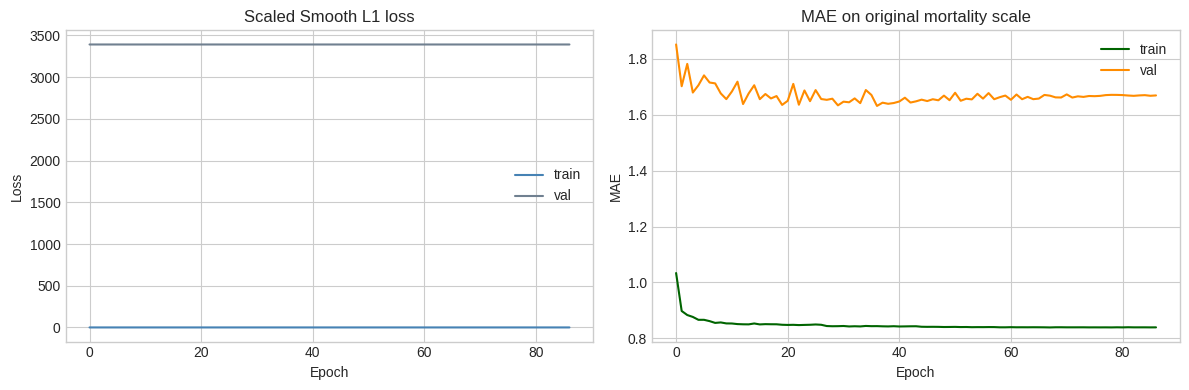

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train", color="steelblue")
axes[0].plot(history["val_loss"], label="val", color="slategray")
axes[0].set_title("Scaled Smooth L1 loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_mae"], label="train", color="darkgreen")
axes[1].plot(history["val_mae"], label="val", color="darkorange")
axes[1].set_title("MAE on original mortality scale")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9 - Evaluate on held-out windows and inspect one forecast


Test loss : 803.3647
Test MAE  : 0.7977
Horizon-wise test MAE:
  t+1: 0.7959
  t+2: 0.7994
  t+3: 0.7997
  t+4: 0.7957


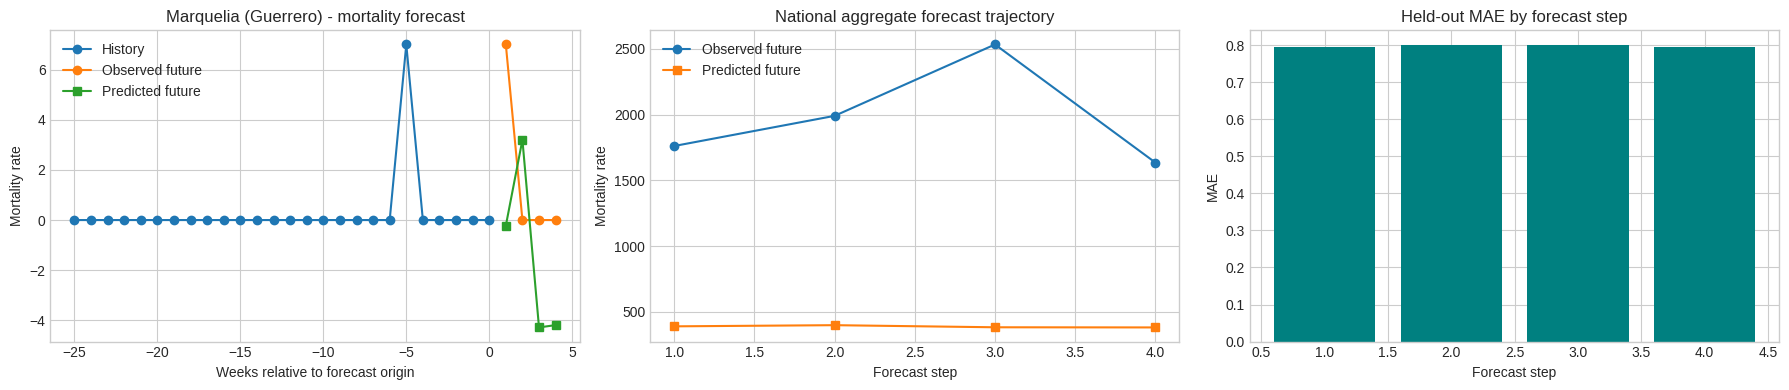

In [9]:
test_loss, test_mae = run_epoch(test_loader, training=False)
test_pred, test_target = predict_loader(test_loader)
horizon_mae = torch.abs(test_pred - test_target).mean(dim=0)

print(f"Test loss : {test_loss:.4f}")
print(f"Test MAE  : {test_mae:.4f}")
print("Horizon-wise test MAE:")
for step, value in enumerate(horizon_mae.tolist(), start=1):
    print(f"  t+{step}: {value:.4f}")

example = test_dataset[0]
example_batch = Batch.from_data_list([example]).to(device)

model.eval()
with torch.no_grad():
    pred_scaled = model(example_batch)

history_orig = restore_mortality(example_batch.x[..., 0]).cpu()
target_orig = restore_mortality(example_batch.y).cpu()
pred_orig = restore_mortality(pred_scaled).cpu()

example_node = mortality_df.mean(axis=0).sort_values(ascending=False).index[0]
example_label = (
    f"{node_frame.loc[example_node, 'municipality']} "
    f"({node_frame.loc[example_node, 'state']})"
)

history_axis = np.arange(-WINDOW_WEEKS + 1, 1)
forecast_axis = np.arange(1, HORIZON_WEEKS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(
    history_axis,
    history_orig[example_node].numpy(),
    marker="o",
    linewidth=1.5,
    label="History",
)
axes[0].plot(
    forecast_axis,
    target_orig[example_node].numpy(),
    marker="o",
    linewidth=1.5,
    label="Observed future",
)
axes[0].plot(
    forecast_axis,
    pred_orig[example_node].numpy(),
    marker="s",
    linewidth=1.5,
    label="Predicted future",
)
axes[0].set_title(f"{example_label} - mortality forecast")
axes[0].set_xlabel("Weeks relative to forecast origin")
axes[0].set_ylabel("Mortality rate")
axes[0].legend()

national_true = target_orig.sum(dim=0).numpy()
national_pred = pred_orig.sum(dim=0).numpy()

axes[1].plot(
    forecast_axis,
    national_true,
    marker="o",
    linewidth=1.5,
    label="Observed future",
)
axes[1].plot(
    forecast_axis,
    national_pred,
    marker="s",
    linewidth=1.5,
    label="Predicted future",
)
axes[1].set_title("National aggregate forecast trajectory")
axes[1].set_xlabel("Forecast step")
axes[1].set_ylabel("Mortality rate")
axes[1].legend()

axes[2].bar(forecast_axis, horizon_mae.numpy(), color="teal")
axes[2].set_title("Held-out MAE by forecast step")
axes[2].set_xlabel("Forecast step")
axes[2].set_ylabel("MAE")

plt.tight_layout()
plt.show()


In [10]:
node_error_sum = torch.zeros(NUM_NODES)
node_error_count = torch.zeros(NUM_NODES)

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch)
        abs_error = torch.abs(restore_mortality(pred) - restore_mortality(batch.y))
        per_node_error = abs_error.mean(dim=1).cpu()
        node_ids = torch.arange(per_node_error.size(0)) % NUM_NODES
        node_error_sum.index_add_(0, node_ids, per_node_error)
        node_error_count.index_add_(0, node_ids, torch.ones_like(per_node_error))

node_test_mae = node_error_sum / node_error_count.clamp_min(1.0)

error_frame = node_frame.assign(
    mean_mortality=mortality_df.mean(axis=0).values,
    mean_lst=lst_df.mean(axis=0, skipna=True).values,
    mean_precipitation=precip_df.mean(axis=0, skipna=True).values,
    test_mae=node_test_mae.numpy(),
).sort_values("test_mae", ascending=False)

error_frame.head(10)


,municipality,state,longitude,latitude,cvegeo,mean_mortality,mean_lst,mean_precipitation,test_mae
node,,,,,,,,,
1157,Santa Magdalena Jicotlán,Oaxaca,-97.481790,17.806607,20047,2.150815,20.150035,0.000000,15.882130
1009,Melchor Ocampo,Nuevo León,-99.493516,26.048931,19035,2.022000,25.701081,4.884179,11.593011
1225,San Bartolo Coyotepec,Oaxaca,-96.695615,16.941142,20115,13.092971,NaN,0.748924,8.186520
1276,San Jerónimo Tecóatl,Oaxaca,-96.929032,18.153798,20163,4.584632,NaN,0.000000,7.383576
1094,San Pedro Topiltepec,Oaxaca,-97.357436,17.455246,20332,1.401201,20.710348,0.884024,6.905441
1112,San Pedro y San Pablo Ayutla,Oaxaca,-96.134983,17.021742,20337,3.383420,18.202043,0.803881,5.973207
1253,San Francisco Cajonos,Oaxaca,-96.264646,17.180862,20138,8.884631,17.728276,0.000000,5.896852
934,Tetecala,Morelos,-99.412394,18.692736,17021,3.510852,27.056846,0.000000,5.777966
1760,Axutla,Puebla,-98.393508,18.184683,21024,1.875716,27.333564,1.084244,5.298465


## 10 - Rolling-origin backtesting vs current held-out metrics

To test temporal robustness, we evaluate the trained model at multiple forecast origins inside the held-out test region. Each origin predicts the next `HORIZON_WEEKS`, and we compare those errors against the single held-out test metrics.


Rolling-origin summary vs current held-out metrics


,metric,value
0,Current held-out test MAE,0.7977
1,Rolling-origin mean MAE,0.8019
2,Rolling-origin MAE std,0.1247
3,Rolling-origin MAE min,0.6672
4,Rolling-origin MAE max,1.0447
5,Mean delta vs current test MAE,0.0042


Per-origin MAE (lower is better)


,forecast_origin,origin_mae,t+1,t+2,t+3,t+4
0,2023/23,0.7922,0.7119,0.7928,1.0028,0.6613
1,2023/31,0.6924,0.7327,0.7552,0.6327,0.6492
2,2023/40,0.7796,0.6635,0.7316,0.7775,0.9457
3,2023/49,1.0160,0.7850,0.9093,1.3196,1.0502
4,2024/05,1.0447,1.1301,0.9633,0.9160,1.1696
5,2024/14,0.7891,0.8049,0.7948,0.8538,0.7030
6,2024/23,0.8291,0.8732,0.9414,0.7468,0.7551
7,2024/31,0.6994,0.7572,0.6894,0.7124,0.6384
8,2024/40,0.7092,0.8274,0.5428,0.7003,0.7665
9,2024/49,0.6672,0.7233,0.7208,0.6376,0.5870


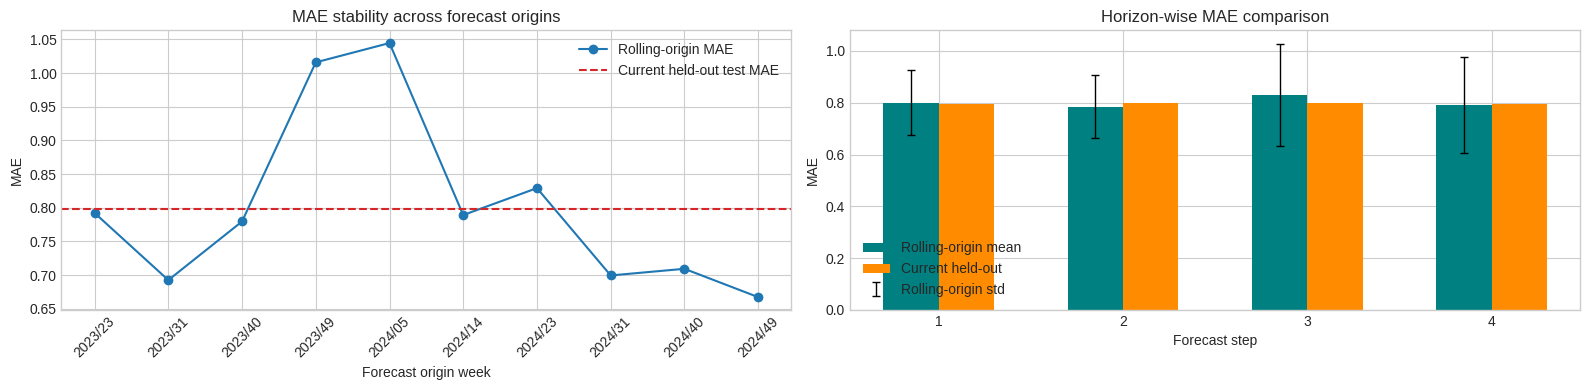

In [11]:
def evaluate_origin(start_idx):
    history = scaled_dynamic_tensor[
        start_idx : start_idx + WINDOW_WEEKS
    ].permute(1, 0, 2).contiguous()
    target = target_tensor[
        start_idx + WINDOW_WEEKS : start_idx + WINDOW_WEEKS + HORIZON_WEEKS
    ].T.contiguous()

    data = Data(
        x=history,
        y=target,
        static=scaled_static_tensor,
        edge_index=edge_index,
        edge_weight=edge_weight,
    )
    batch = Batch.from_data_list([data]).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(batch)

    pred_orig = restore_mortality(pred).cpu()
    target_orig = restore_mortality(batch.y).cpu()
    abs_error = torch.abs(pred_orig - target_orig)

    metrics = {
        "origin_start_idx": start_idx,
        "forecast_origin": str(week_labels[start_idx + WINDOW_WEEKS]),
        "origin_mae": abs_error.mean().item(),
    }
    for step in range(HORIZON_WEEKS):
        metrics[f"t+{step + 1}"] = abs_error[:, step].mean().item()
    return metrics


num_backtest_origins = 10
if len(test_starts) <= num_backtest_origins:
    selected_origins = list(test_starts)
else:
    sampled_idx = np.linspace(
        0, len(test_starts) - 1, num=num_backtest_origins, dtype=int
    )
    selected_origins = [test_starts[i] for i in sampled_idx]

rolling_rows = [evaluate_origin(start_idx) for start_idx in selected_origins]
rolling_df = pd.DataFrame(rolling_rows)

horizon_cols = [f"t+{step}" for step in range(1, HORIZON_WEEKS + 1)]
rolling_horizon_mean = rolling_df[horizon_cols].mean(axis=0)
rolling_horizon_std = rolling_df[horizon_cols].std(axis=0, ddof=0)

comparison_frame = pd.DataFrame(
    [
        {
            "metric": "Current held-out test MAE",
            "value": float(test_mae),
        },
        {
            "metric": "Rolling-origin mean MAE",
            "value": float(rolling_df["origin_mae"].mean()),
        },
        {
            "metric": "Rolling-origin MAE std",
            "value": float(rolling_df["origin_mae"].std(ddof=0)),
        },
        {
            "metric": "Rolling-origin MAE min",
            "value": float(rolling_df["origin_mae"].min()),
        },
        {
            "metric": "Rolling-origin MAE max",
            "value": float(rolling_df["origin_mae"].max()),
        },
        {
            "metric": "Mean delta vs current test MAE",
            "value": float(rolling_df["origin_mae"].mean() - test_mae),
        },
    ]
)

print("Rolling-origin summary vs current held-out metrics")
display(comparison_frame.style.format({"value": "{:.4f}"}))

print("Per-origin MAE (lower is better)")
display(
    rolling_df
    .sort_values("origin_start_idx")
    .reset_index(drop=True)[["forecast_origin", "origin_mae"] + horizon_cols]
    .style.format({col: "{:.4f}" for col in ["origin_mae"] + horizon_cols})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(
    rolling_df["forecast_origin"],
    rolling_df["origin_mae"],
    marker="o",
    linewidth=1.5,
    color="tab:blue",
    label="Rolling-origin MAE",
)
axes[0].axhline(
    y=test_mae,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label="Current held-out test MAE",
)
axes[0].set_title("MAE stability across forecast origins")
axes[0].set_xlabel("Forecast origin week")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

x_axis = np.arange(1, HORIZON_WEEKS + 1)
axes[1].bar(
    x_axis - 0.15,
    rolling_horizon_mean.values,
    width=0.30,
    color="teal",
    label="Rolling-origin mean",
)
axes[1].bar(
    x_axis + 0.15,
    horizon_mae.numpy(),
    width=0.30,
    color="darkorange",
    label="Current held-out",
)
axes[1].errorbar(
    x_axis - 0.15,
    rolling_horizon_mean.values,
    yerr=rolling_horizon_std.values,
    fmt="none",
    ecolor="black",
    capsize=3,
    linewidth=1,
    label="Rolling-origin std",
)
axes[1].set_title("Horizon-wise MAE comparison")
axes[1].set_xlabel("Forecast step")
axes[1].set_ylabel("MAE")
axes[1].set_xticks(x_axis)
axes[1].legend()

plt.tight_layout()
plt.show()


Backtesting diagnostic summary


,metric,value
0,Current held-out MAE,0.7977
1,Rolling-origin mean MAE,0.8019
2,Difficult-origin threshold (mean + 1 std),0.9266
3,Difficult origins found,2.0000


Difficult forecast-origin weeks


,forecast_origin,origin_mae,origin_level,origin_volatility,level_vs_avg_pct,vol_vs_avg_pct
0,2024/05,1.0447,2654.02,379.66,+32.7%,+35.9%
1,2023/49,1.0160,2609.87,205.29,+30.5%,-26.5%


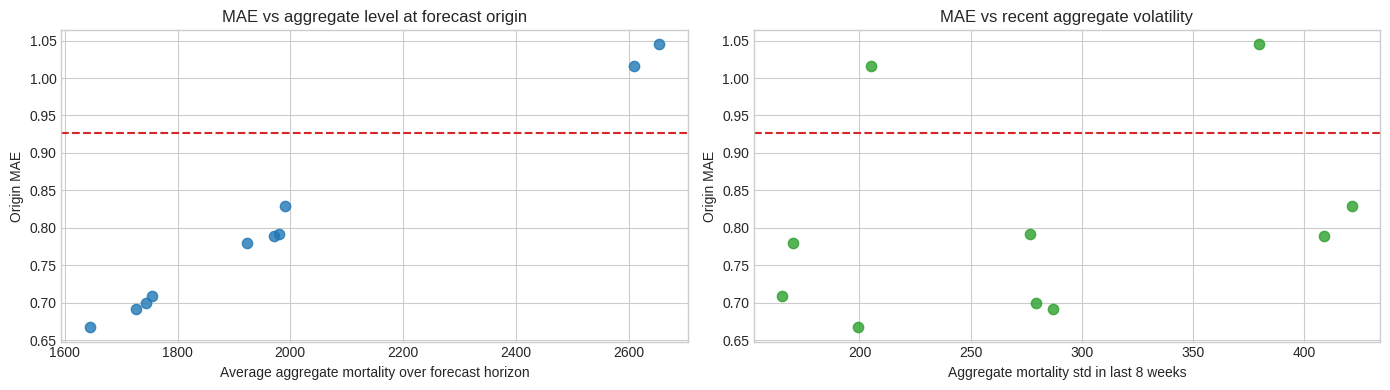

In [12]:
rolling_summary = rolling_df.copy()
rolling_summary["origin_level"] = [
    float(
        mortality_df.iloc[
            start_idx + WINDOW_WEEKS : start_idx + WINDOW_WEEKS + HORIZON_WEEKS
        ].sum(axis=1).mean()
    )
    for start_idx in rolling_summary["origin_start_idx"]
]
rolling_summary["origin_volatility"] = [
    float(
        mortality_df.iloc[
            start_idx + WINDOW_WEEKS - 8 : start_idx + WINDOW_WEEKS
        ].sum(axis=1).std(ddof=0)
    )
    for start_idx in rolling_summary["origin_start_idx"]
]

threshold = float(
    rolling_summary["origin_mae"].mean() + rolling_summary["origin_mae"].std(ddof=0)
)
difficult_origins = (
    rolling_summary[rolling_summary["origin_mae"] >= threshold]
    .sort_values("origin_mae", ascending=False)
    .reset_index(drop=True)
)

overall_level = float(rolling_summary["origin_level"].mean())
overall_volatility = float(rolling_summary["origin_volatility"].mean())

summary_frame = pd.DataFrame(
    [
        {"metric": "Current held-out MAE", "value": float(test_mae)},
        {
            "metric": "Rolling-origin mean MAE",
            "value": float(rolling_summary["origin_mae"].mean()),
        },
        {
            "metric": "Difficult-origin threshold (mean + 1 std)",
            "value": threshold,
        },
        {"metric": "Difficult origins found", "value": float(len(difficult_origins))},
    ]
)

print("Backtesting diagnostic summary")
display(summary_frame.style.format({"value": "{:.4f}"}))

if difficult_origins.empty:
    print(
        "No difficult origins above threshold. The model appears stable across sampled origins."
    )
else:
    difficult_report = difficult_origins[
        [
            "forecast_origin",
            "origin_mae",
            "origin_level",
            "origin_volatility",
        ]
    ].copy()
    difficult_report["level_vs_avg_pct"] = (
        100.0 * (difficult_report["origin_level"] - overall_level) / max(overall_level, 1e-8)
    )
    difficult_report["vol_vs_avg_pct"] = (
        100.0
        * (difficult_report["origin_volatility"] - overall_volatility)
        / max(overall_volatility, 1e-8)
    )

    print("Difficult forecast-origin weeks")
    display(
        difficult_report.style.format(
            {
                "origin_mae": "{:.4f}",
                "origin_level": "{:.2f}",
                "origin_volatility": "{:.2f}",
                "level_vs_avg_pct": "{:+.1f}%",
                "vol_vs_avg_pct": "{:+.1f}%",
            }
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].scatter(
        rolling_summary["origin_level"],
        rolling_summary["origin_mae"],
        s=55,
        alpha=0.8,
        color="tab:blue",
    )
    axes[0].axhline(threshold, color="tab:red", linestyle="--", linewidth=1.5)
    axes[0].set_title("MAE vs aggregate level at forecast origin")
    axes[0].set_xlabel("Average aggregate mortality over forecast horizon")
    axes[0].set_ylabel("Origin MAE")

    axes[1].scatter(
        rolling_summary["origin_volatility"],
        rolling_summary["origin_mae"],
        s=55,
        alpha=0.8,
        color="tab:green",
    )
    axes[1].axhline(threshold, color="tab:red", linestyle="--", linewidth=1.5)
    axes[1].set_title("MAE vs recent aggregate volatility")
    axes[1].set_xlabel("Aggregate mortality std in last 8 weeks")
    axes[1].set_ylabel("Origin MAE")

    plt.tight_layout()
    plt.show()


## 11 - Full validation and test forecast vs observed for a single node

Run the trained model over every window in the validation and test regions and visualize the predicted vs observed mortality for a chosen municipality. Because windows overlap (`STRIDE=1`), multiple predictions exist for the same week and are averaged.


  - validation region
  - test region


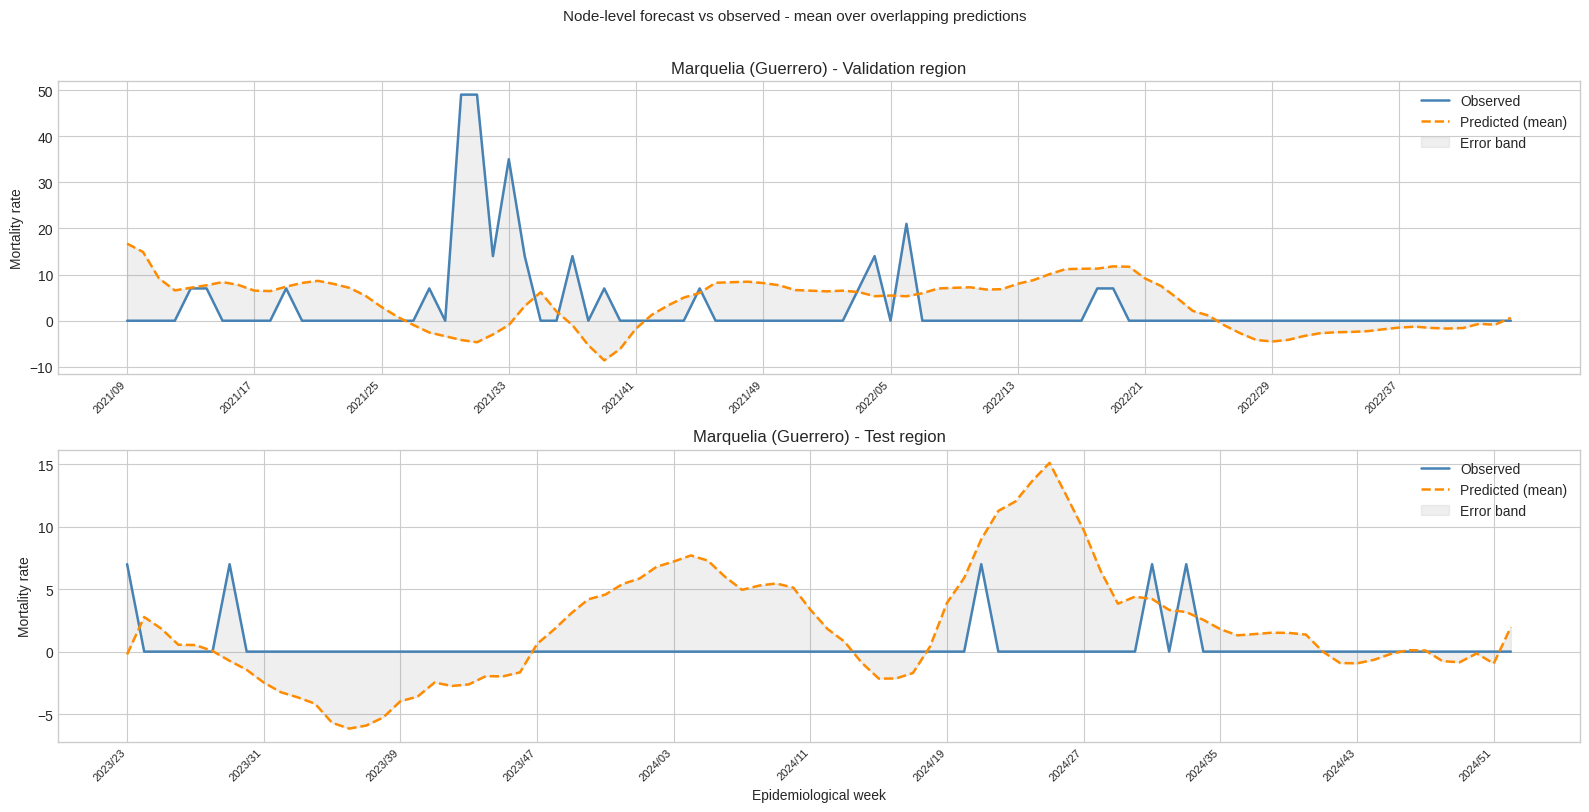

In [13]:
focus_node_idx = example_node
focus_label = (
    f"{node_frame.loc[focus_node_idx, 'municipality']} "
    f"({node_frame.loc[focus_node_idx, 'state']})"
)


def predict_node_over_region(dataset, node_id):
    rows = []
    model.eval()
    with torch.no_grad():
        for i in range(len(dataset)):
            sample = dataset[i]
            batch = Batch.from_data_list([sample]).to(device)
            pred = model(batch)
            pred_orig = restore_mortality(pred).cpu()
            target_orig = restore_mortality(batch.y).cpu()
            t0 = int(sample.window_start.item()) + WINDOW_WEEKS
            for step in range(HORIZON_WEEKS):
                rows.append(
                    {
                        "week_idx": t0 + step,
                        "predicted": pred_orig[node_id, step].item(),
                        "observed": target_orig[node_id, step].item(),
                    }
                )
    return pd.DataFrame(rows)


print(f"Collecting predictions for: {focus_label}")
print("  - validation region")
val_preds_df = predict_node_over_region(val_dataset, focus_node_idx)
print("  - test region")
test_preds_df = predict_node_over_region(test_dataset, focus_node_idx)

val_agg = val_preds_df.groupby("week_idx")[["predicted", "observed"]].mean().reset_index()
test_agg = test_preds_df.groupby("week_idx")[["predicted", "observed"]].mean().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
tick_step = 8

for ax, agg_df, title_suffix in [
    (axes[0], val_agg, "Validation region"),
    (axes[1], test_agg, "Test region"),
]:
    xs = agg_df["week_idx"].values
    obs = agg_df["observed"].values
    prd = agg_df["predicted"].values

    ax.plot(xs, obs, linewidth=1.8, color="steelblue", label="Observed")
    ax.plot(xs, prd, linewidth=1.8, color="darkorange", linestyle="--", label="Predicted (mean)")
    ax.fill_between(xs, obs, prd, alpha=0.12, color="gray", label="Error band")

    tick_pos = xs[::tick_step]
    tick_lbl = [str(week_labels[i]) for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"{focus_label} - {title_suffix}")
    ax.set_ylabel("Mortality rate")
    ax.legend(loc="upper right")

axes[1].set_xlabel("Epidemiological week")
plt.suptitle(
    "Node-level forecast vs observed - mean over overlapping predictions",
    fontsize=11,
    y=1.01,
)
plt.tight_layout()
plt.show()


## 12 - Inspect the multimodal context for the example municipality

This shows the actual input window the model sees for one municipality: mortality, LST, precipitation, and the static coordinates carried with every graph sample.


Static attributes used by the model for this municipality


,cvegeo,municipality,state,latitude,longitude
node,,,,,
384,12077,Marquelia,Guerrero,16.638964,-98.745024


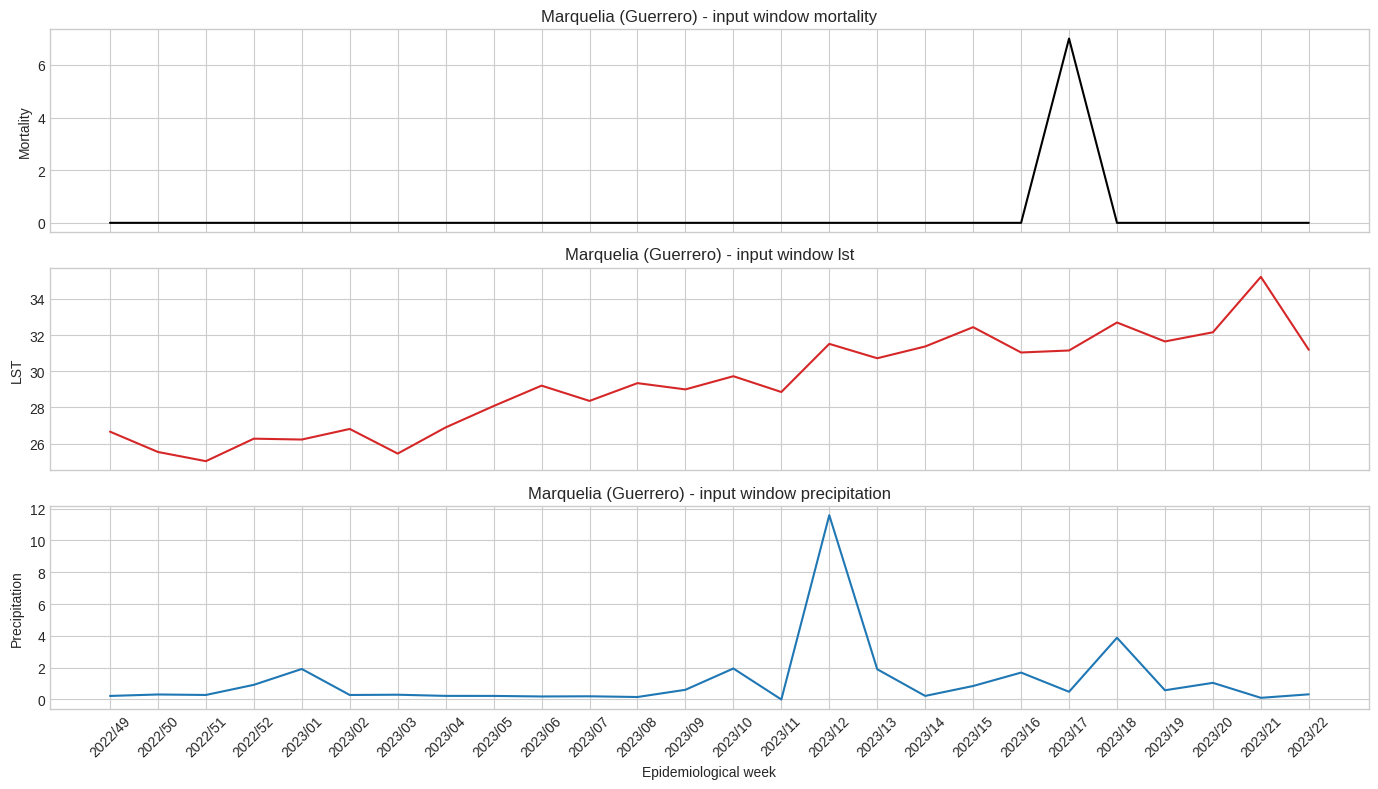

In [14]:
context_start_idx = int(example.window_start.item())
context_weeks = week_labels[context_start_idx : context_start_idx + WINDOW_WEEKS]

context_frame = pd.DataFrame(
    {
        "mortality": mortality_df.iloc[
            context_start_idx : context_start_idx + WINDOW_WEEKS,
            example_node,
        ].values,
        "lst": lst_df.iloc[
            context_start_idx : context_start_idx + WINDOW_WEEKS,
            example_node,
        ].values,
        "precipitation": precip_df.iloc[
            context_start_idx : context_start_idx + WINDOW_WEEKS,
            example_node,
        ].values,
    },
    index=context_weeks,
)

print("Static attributes used by the model for this municipality")
display(
    node_frame.loc[
        [example_node],
        ["cvegeo", "municipality", "state", "latitude", "longitude"],
    ]
)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, column, color, ylabel in [
    (axes[0], "mortality", "black", "Mortality"),
    (axes[1], "lst", "tab:red", "LST"),
    (axes[2], "precipitation", "tab:blue", "Precipitation"),
]:
    ax.plot(context_frame.index, context_frame[column], color=color, linewidth=1.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{example_label} - input window {column}")

axes[2].set_xlabel("Epidemiological week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 13 - Useful extensions

- Add more static attributes, such as elevation, population, or state-level indicators.
- Add lagged or rolling weather summaries if you want the model to see slower environmental effects.
- Replace GraphSAGE with GATConv or a custom spatio-temporal message-passing block.
- Compare against the mortality-only notebook as an ablation baseline.
- If future weather forecasts are available, inject forecasted exogenous variables at inference time.
